In [15]:
# ==============================================================================
# CELL 1: SETUP AND CALCULATE GLOBAL DATASET STATISTICS (RUN ONCE)
# ==============================================================================
import os
import zipfile
import numpy as np
from tqdm import tqdm
from google.colab import drive

# --- 1. MOUNT DRIVE AND UNZIP DATA ---
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/UNet_Wetland_Dataset_v2.zip"
LOCAL_EXTRACT_PATH = "/content/UNet_Dataset"

if not os.path.exists(LOCAL_EXTRACT_PATH):
    print("Unzipping dataset to local SSD...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_PATH)
    print("Unzip complete!")
else:
    print("Dataset already unzipped.")

# --- 2. CALCULATE GLOBAL STATS ---
train_img_dir = os.path.join(LOCAL_EXTRACT_PATH, "train", "images")
train_files = [f for f in os.listdir(train_img_dir) if f.endswith('.npy')]

# Initialize arrays to hold the sum and sum of squares for all 64 channels
channel_sum = np.zeros(64, dtype=np.float64)
channel_sum_sq = np.zeros(64, dtype=np.float64)
total_pixels = 0

for file_name in tqdm(train_files, desc="Calculating global stats"):
    img = np.load(os.path.join(train_img_dir, file_name)).astype(np.float32)

    # img shape is assumed to be (64, H, W)
    H, W = img.shape[1], img.shape[2]
    total_pixels += H * W

    # Sum across spatial dimensions (H, W) for each channel
    channel_sum += img.sum(axis=(1, 2))
    channel_sum_sq += (img ** 2).sum(axis=(1, 2))

# Calculate final global mean and std
global_mean = channel_sum / total_pixels
global_var = (channel_sum_sq / total_pixels) - (global_mean ** 2)
global_std = np.sqrt(np.maximum(global_var, 1e-8)) # prevent division by zero

print("\n\n--- COPY THESE ARRAYS INTO CELL 2 ---")
print(f"GLOBAL_MEAN = np.array({global_mean.tolist()})")
print(f"GLOBAL_STD = np.array({global_std.tolist()})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already unzipped.


Calculating global stats:   1%|          | 283/35979 [00:05<11:47, 50.45it/s]


KeyboardInterrupt: 

In [14]:
# ==============================================================================
# CELL 2: U-NET TRAINING PIPELINE (MULTI-CLASS WITH IMBALANCE FIXES)
# ==============================================================================
!pip install -q segmentation-models-pytorch albumentations

import os
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from tqdm import tqdm
from google.colab import drive

# --- 1. CONFIGURATION ---
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_CLASSES = 2 # Background (0) + Wetland Types (1-5)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

drive.mount('/content/drive')

# Unzip dataset
ZIP_PATH = "/content/drive/MyDrive/UNet_Wetland_Dataset_v2.zip"
LOCAL_EXTRACT_PATH = "/content/UNet_Dataset"

if not os.path.exists(LOCAL_EXTRACT_PATH):
    print("Unzipping dataset to local SSD...")
    import zipfile
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_PATH)
    print("Unzip complete!")

# --- 2. DATASET DEFINITION WITH OVERSAMPLING ---
# Global stats from your Cell 1
GLOBAL_MEAN = np.array([0.0492346545614805, -0.11348482535017373, 0.0146184386628794, -0.14347038622335337, 0.0862694653434667, -0.003553442313518676, -0.010346187101392582, 0.11316844250657906, -0.006854947855963677, 0.046787033803770514, -0.0436262683611058, -0.18666068892621762, -0.04777584085794741, -0.03889881447028692, -0.1985601549149602, 0.1639413180110697, 0.04796134046512077, 0.003332134251532814, 0.09500959625047263, -0.013479681891844213, -0.023953312643773927, -0.030151937266955146, 0.06934845013578057, -0.029681929125146538, 0.06073080890116976, 0.05660438121588576, 0.019422980289224227, -0.07600903298584628, 0.1398514935254272, -0.044926573298138414, 0.0687715333922145, -0.07232830352995508, 0.07850318248246688, -0.024611506785646827, -0.07103632947392365, 0.10783158494235164, 0.07654232174127804, 0.11884381224483849, -0.043528281155138626, 0.027237132747798497, -0.09136740712421966, -0.023802806443367592, -0.11564966084115752, -0.03856343556281006, -0.11231874893496065, 0.10010455450704989, 0.059066553499054916, -0.1649313081356141, -0.022282465395715722, -0.17399168135194945, 0.2398904406982983, -0.17068065253953074, -0.08469869151623895, 0.08214233740346592, 0.09248099485948402, 0.018923028537255818, -0.09929096990047384, -0.1337408491902777, -0.10964768209218993, 0.024769493241962835, -0.04380817978466509, 0.028019639216900094, -0.0351877365272146, 0.10905539387332767])
GLOBAL_STD = np.array([0.05797037607790522, 0.07622400968427802, 0.09249475411922252, 0.09455767643247832, 0.0931669749068082, 0.0876768739023364, 0.0722156829312389, 0.0838401648328688, 0.08132713412577972, 0.06604393480114511, 0.09278756988815637, 0.09734059519199757, 0.07751369958737236, 0.048697722523122475, 0.07732053969951945, 0.11438473626078348, 0.05150102926120942, 0.09045237408364867, 0.08848157359883915, 0.09658649494135513, 0.06749301907490499, 0.08428312698498876, 0.059670770945098456, 0.07013218234767118, 0.07308722428478416, 0.07004237199661413, 0.11636733697451576, 0.1368272893043805, 0.06205087082979258, 0.06933838852505449, 0.075288511203836, 0.11333948828339387, 0.08999299755280449, 0.10004123576265733, 0.07741094727725105, 0.10056023942761705, 0.06792428728835682, 0.07023020313966781, 0.07113273705273832, 0.08969045103683389, 0.1017809207028836, 0.07956413208943076, 0.07821871598628748, 0.09554687964519179, 0.08908247043233766, 0.07032003456543644, 0.0924487732990756, 0.08924469967431391, 0.08058255102086201, 0.09309689239035969, 0.09070817379703305, 0.08265517430619343, 0.0501954320515144, 0.08375907770092184, 0.08924597402688475, 0.10607233864204692, 0.08233114296547643, 0.0686378767430524, 0.06646077964780783, 0.08738608978985982, 0.05764458428729796, 0.06785532529227671, 0.09461412380888849, 0.06745224154454373])

class WetlandDataset(Dataset):
    def __init__(self, split="train", transform=None, oversample_rare=False):
        self.img_dir = os.path.join(LOCAL_EXTRACT_PATH, split, "images")
        self.mask_dir = os.path.join(LOCAL_EXTRACT_PATH, split, "masks")
        base_files = [f for f in os.listdir(self.img_dir) if f.endswith('.npy')]
        self.transform = transform

        # --- FIX #2: PATCH OVERSAMPLING ---
        if split == "train" and oversample_rare:
            print("Scanning training masks to oversample rare wetland classes...")
            oversampled_files = []
            for f in tqdm(base_files, desc="Oversampling"):
                mask = np.load(os.path.join(self.mask_dir, f))
                oversampled_files.append(f) # Always add the patch once

                # Heavily oversample Bog (Class 1) patches
                if 1 in mask:
                    oversampled_files.extend([f] * 15)
                # Moderately oversample Open Water (Class 5) patches
                elif 5 in mask:
                    oversampled_files.extend([f] * 3)

            self.files = oversampled_files
            print(f"Original training patches: {len(base_files)} | Total after oversampling: {len(self.files)}")
        else:
            self.files = base_files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        img = np.load(os.path.join(self.img_dir, file_name)).astype(np.float32)
        mask = np.load(os.path.join(self.mask_dir, file_name)).astype(np.float32)

        # Vectorized Global Normalization
        img = (img - GLOBAL_MEAN.reshape(64, 1, 1)) / GLOBAL_STD.reshape(64, 1, 1)

        # --- NEW: Binarize the mask for the CNN ---
        # Class 0 remains 0 (Background). All other classes (>0) become 1 (Wetland)
        mask = (mask > 0).astype(np.float32)

        # Apply spatial augmentations if provided
        if self.transform:
            img = np.transpose(img, (1, 2, 0))
            transformed = self.transform(image=img, mask=mask)
            img = np.transpose(transformed['image'], (2, 0, 1))
            mask = transformed['mask']

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

# --- 3. AUGMENTATIONS & DATALOADERS ---
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5)
])

# Activate oversampling for the training set only
train_dataset = WetlandDataset(split="train", transform=train_transform, oversample_rare=True)
val_dataset = WetlandDataset(split="val", transform=None, oversample_rare=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# --- 4. MODEL SETUP & EXPLICIT WEIGHTS ---
class EarthEngineUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=64,
            classes=NUM_CLASSES,
            activation=None
        )

    def forward(self, x):
        return self.unet(x)

model = EarthEngineUNet().to(DEVICE)

# --- FIX #1: EXPLICIT CLASS WEIGHTS (SMOOTHED) ---
# Weights softened (using square root scaling) to prevent hallucination
# while still protecting minority classes.
class_weights = torch.tensor([1.0, 2.0], dtype=torch.float32).to(DEVICE)

# Weighted Cross Entropy strictly punishes the model for missing rare classes
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda')

# --- FIX #3: STRICT MACRO IOU TRACKING ---
# The scheduler is now explicitly bound to the Macro IoU score
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

def calculate_iou(outputs, masks, num_classes=NUM_CLASSES, eps=1e-7):
    preds = torch.argmax(outputs, dim=1)
    iou_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c)
        mask_c = (masks == c)
        intersection = (pred_c & mask_c).sum((1, 2)).float()
        union = (pred_c | mask_c).sum((1, 2)).float()
        iou = (intersection + eps) / (union + eps)
        iou_per_class.append(iou.mean().item())

    return np.mean(iou_per_class) * 100

# --- 5. TRAINING LOOP ---
best_val_iou = 0.0
save_path = "/content/drive/MyDrive/best_wetland_unet_v10.pth"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # -- TRAIN --
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc="Training"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # -- VALIDATION --
    model.eval()
    val_loss = 0.0
    val_iou_total = 0.0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validating"):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou_total += calculate_iou(outputs, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou_total / len(val_loader)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro IoU: {avg_val_iou:.2f}%")

    # Scheduler steps exclusively based on Macro IoU improvements
    scheduler.step(avg_val_iou)

    # Save only when Macro IoU improves
    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        torch.save(model.state_dict(), save_path)
        print(f"⭐ New best model saved with Macro IoU: {best_val_iou:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scanning training masks to oversample rare wetland classes...


Oversampling: 100%|██████████| 35979/35979 [00:20<00:00, 1721.29it/s]


Original training patches: 35979 | Total after oversampling: 57396

Epoch 1/20


Validating: 100%|██████████| 398/398 [04:18<00:00,  1.54it/s]


Train Loss: 0.2277 | Val Loss: 0.2105 | Val Macro IoU: 67.83%
⭐ New best model saved with Macro IoU: 67.83%

Epoch 2/20


...

Train Loss: 0.1342 | Val Loss: 0.2062 | Val Macro IoU: 70.76%

Epoch 19/20


Validating: 100%|██████████| 398/398 [04:18<00:00,  1.54it/s]


Train Loss: 0.1279 | Val Loss: 0.2064 | Val Macro IoU: 70.68%

Epoch 20/20


Validating: 100%|██████████| 398/398 [04:18<00:00,  1.54it/s]

Train Loss: 0.1258 | Val Loss: 0.2107 | Val Macro IoU: 70.94%


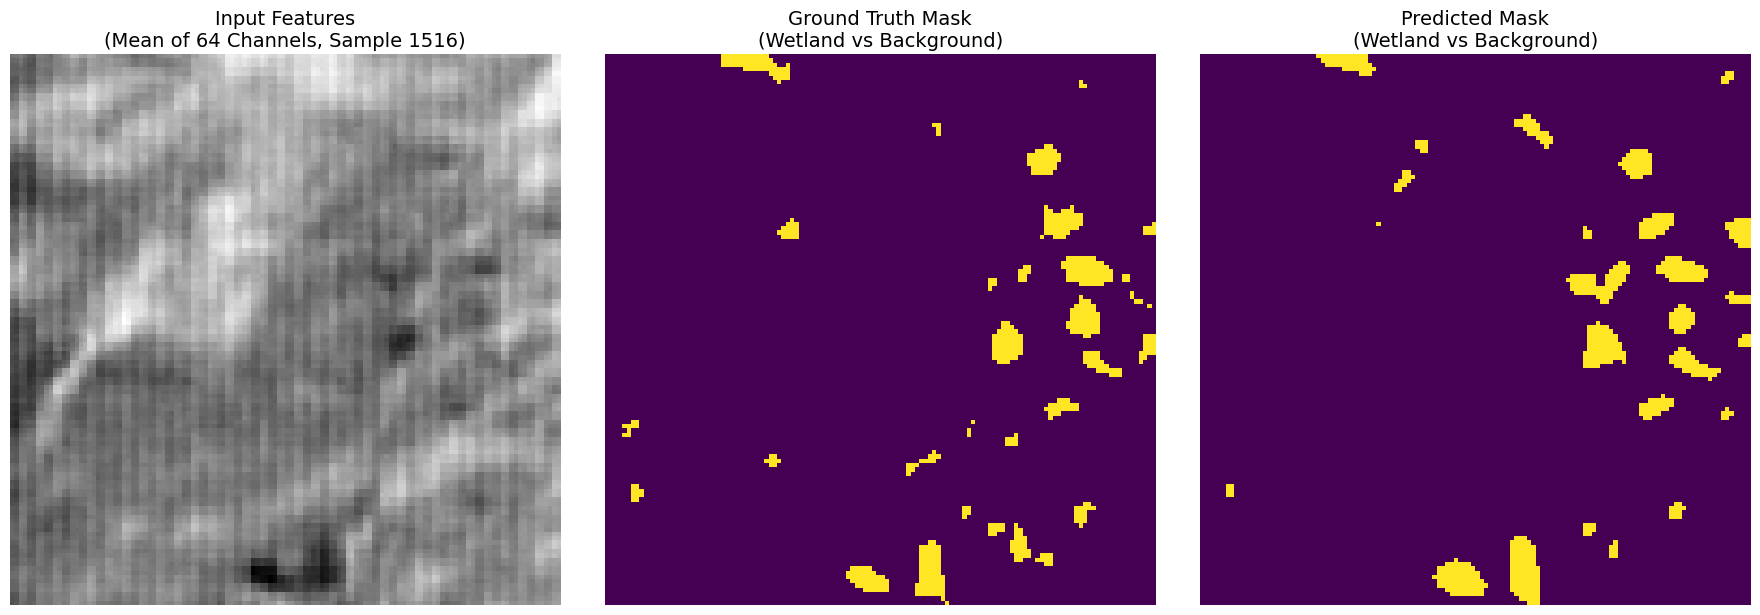

In [17]:
# ==============================================================================
# CELL 3: VISUAL INFERENCE AND COMPARISON (BINARY)
# ==============================================================================
import matplotlib.pyplot as plt
import random
import torch

# 1. Initialize the custom model architecture
model = EarthEngineUNet().to(DEVICE)

# 2. Load the best saved model weights
model.load_state_dict(torch.load(save_path))
model.eval()

# Pick a random sample from the validation set
idx = random.randint(0, len(val_dataset) - 1)
image, true_mask = val_dataset[idx]

# Run inference
with torch.no_grad():
    # Add batch dimension and send to device
    image_input = image.unsqueeze(0).to(DEVICE)

    # Get raw logits from the model
    with torch.amp.autocast('cuda'):
        output = model(image_input)

    # Collapse the 2 probability channels into a single prediction map
    pred_mask = torch.argmax(output, dim=1).cpu().squeeze().numpy()

# Prepare arrays for visualization
true_mask_vis = true_mask.squeeze().numpy()

# Average the 64 Earth Engine channels to create a single rough grayscale image
image_vis = image.mean(dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_vis, cmap='gray')
axes[0].set_title(f"Input Features\n(Mean of 64 Channels, Sample {idx})", fontsize=14)
axes[0].axis('off')

# Use a binary/sequential colormap (like 'viridis' or 'magma') for 0 vs 1
axes[1].imshow(true_mask_vis, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title("Ground Truth Mask\n(Wetland vs Background)", fontsize=14)
axes[1].axis('off')

axes[2].imshow(pred_mask, cmap='viridis', vmin=0, vmax=1)
axes[2].set_title("Predicted Mask\n(Wetland vs Background)", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# ==============================================================================
# CELL 4: COMPREHENSIVE VALIDATION & JSON METRICS EXPORT (V9 ARCHITECTURE)
# ==============================================================================
import os
import json
import torch
import numpy as np
from datetime import datetime
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# --- 1. SETUP & INITIALIZATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 2
save_path = "/content/drive/MyDrive/best_wetland_unet_v10.pth"
output_json_path = "/content/drive/MyDrive/unet_v10_validation_results_2classes.json"

# Redefine the updated 64-channel architecture for standalone execution
class EarthEngineUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=64,
            classes=NUM_CLASSES,
            activation=None
        )

    def forward(self, x):
        return self.unet(x)

print("Loading model and weights...")
model = EarthEngineUNet().to(DEVICE)
model.load_state_dict(torch.load(save_path))
model.eval()

# Initialize an empty confusion matrix of shape (6, 6)
global_cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
total_pixels_processed = 0

# --- 2. INFERENCE LOOP ---
print("Running inference over the validation set...")
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Validating Batches"):
        images = images.to(DEVICE)

        # Get raw logits and use argmax for multi-class prediction
        with torch.amp.autocast('cuda'):
            outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
        labels = masks.numpy().flatten()

        # Calculate confusion matrix for this batch and accumulate
        batch_cm = confusion_matrix(labels, preds, labels=np.arange(NUM_CLASSES))
        global_cm += batch_cm
        total_pixels_processed += len(labels)

# --- 3. METRIC DERIVATION FROM CONFUSION MATRIX ---
# Support (true instances per class)
support = global_cm.sum(axis=1)
total_support = support.sum()

# True Positives, False Positives, False Negatives
tp = np.diag(global_cm)
fp = global_cm.sum(axis=0) - tp
fn = global_cm.sum(axis=1) - tp

# Calculate Per-Class Metrics (with 1e-10 to prevent division by zero)
precision = tp / (tp + fp + 1e-10)
recall = tp / (tp + fn + 1e-10)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)

# Calculate Overall & Weighted Metrics
accuracy = tp.sum() / total_support
weights = support / total_support

precision_weighted = np.sum(precision * weights)
recall_weighted = np.sum(recall * weights)
f1_weighted = np.sum(f1_score * weights)

# Calculate class weights (Inverse Frequency: N / (C * N_i))
class_weights_dict = {}
for i in range(NUM_CLASSES):
    if support[i] > 0:
        class_weights_dict[str(i)] = float(total_support / (NUM_CLASSES * support[i]))
    else:
        class_weights_dict[str(i)] = 0.0

# --- 4. FORMAT DICTIONARY FOR JSON ---
per_class_metrics = {}
for i in range(NUM_CLASSES):
    per_class_metrics[str(i)] = {
        "precision": float(precision[i]),
        "recall": float(recall[i]),
        "f1_score": float(f1_score[i]),
        "support": int(support[i])
    }

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
trained_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

evaluation_results = {
    "version": 1,
    "timestamp": timestamp,
    "trained_datetime": trained_datetime,
    "overall_metrics": {
        "accuracy": float(accuracy),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted)
    },
    "per_class_metrics": per_class_metrics,
    "confusion_matrix": global_cm.tolist(),
    "hyperparameters": {
        "architecture": "smp.Unet (Native 64-Channel)",
        "encoder_name": "resnet34",
        "encoder_weights": "imagenet",
        "batch_size": BATCH_SIZE,
        "loss_functions": "Weighted CrossEntropyLoss"
    },
    "dataset": {
        "source": "UNet_Wetland_Dataset.zip",
        "n_train_patches": len(train_dataset),
        "n_test_patches": len(val_dataset),
        "n_features": 64,
        "total_test_pixels": int(total_pixels_processed)
    },
    "class_weights": class_weights_dict
}

# --- 5. EXPORT TO JSON ---
with open(output_json_path, 'w') as json_file:
    json.dump(evaluation_results, json_file, indent=2)

print(f"\n✅ Validation complete! Results saved to: {output_json_path}")
print(f"Overall Accuracy: {accuracy:.4f} | Weighted F1: {f1_weighted:.4f}")

Loading model and weights...
Running inference over the validation set...


Validating Batches: 100%|██████████| 398/398 [04:25<00:00,  1.50it/s]


✅ Validation complete! Results saved to: /content/drive/MyDrive/unet_v10_validation_results_2classes.json
Overall Accuracy: 0.9462 | Weighted F1: 0.9450


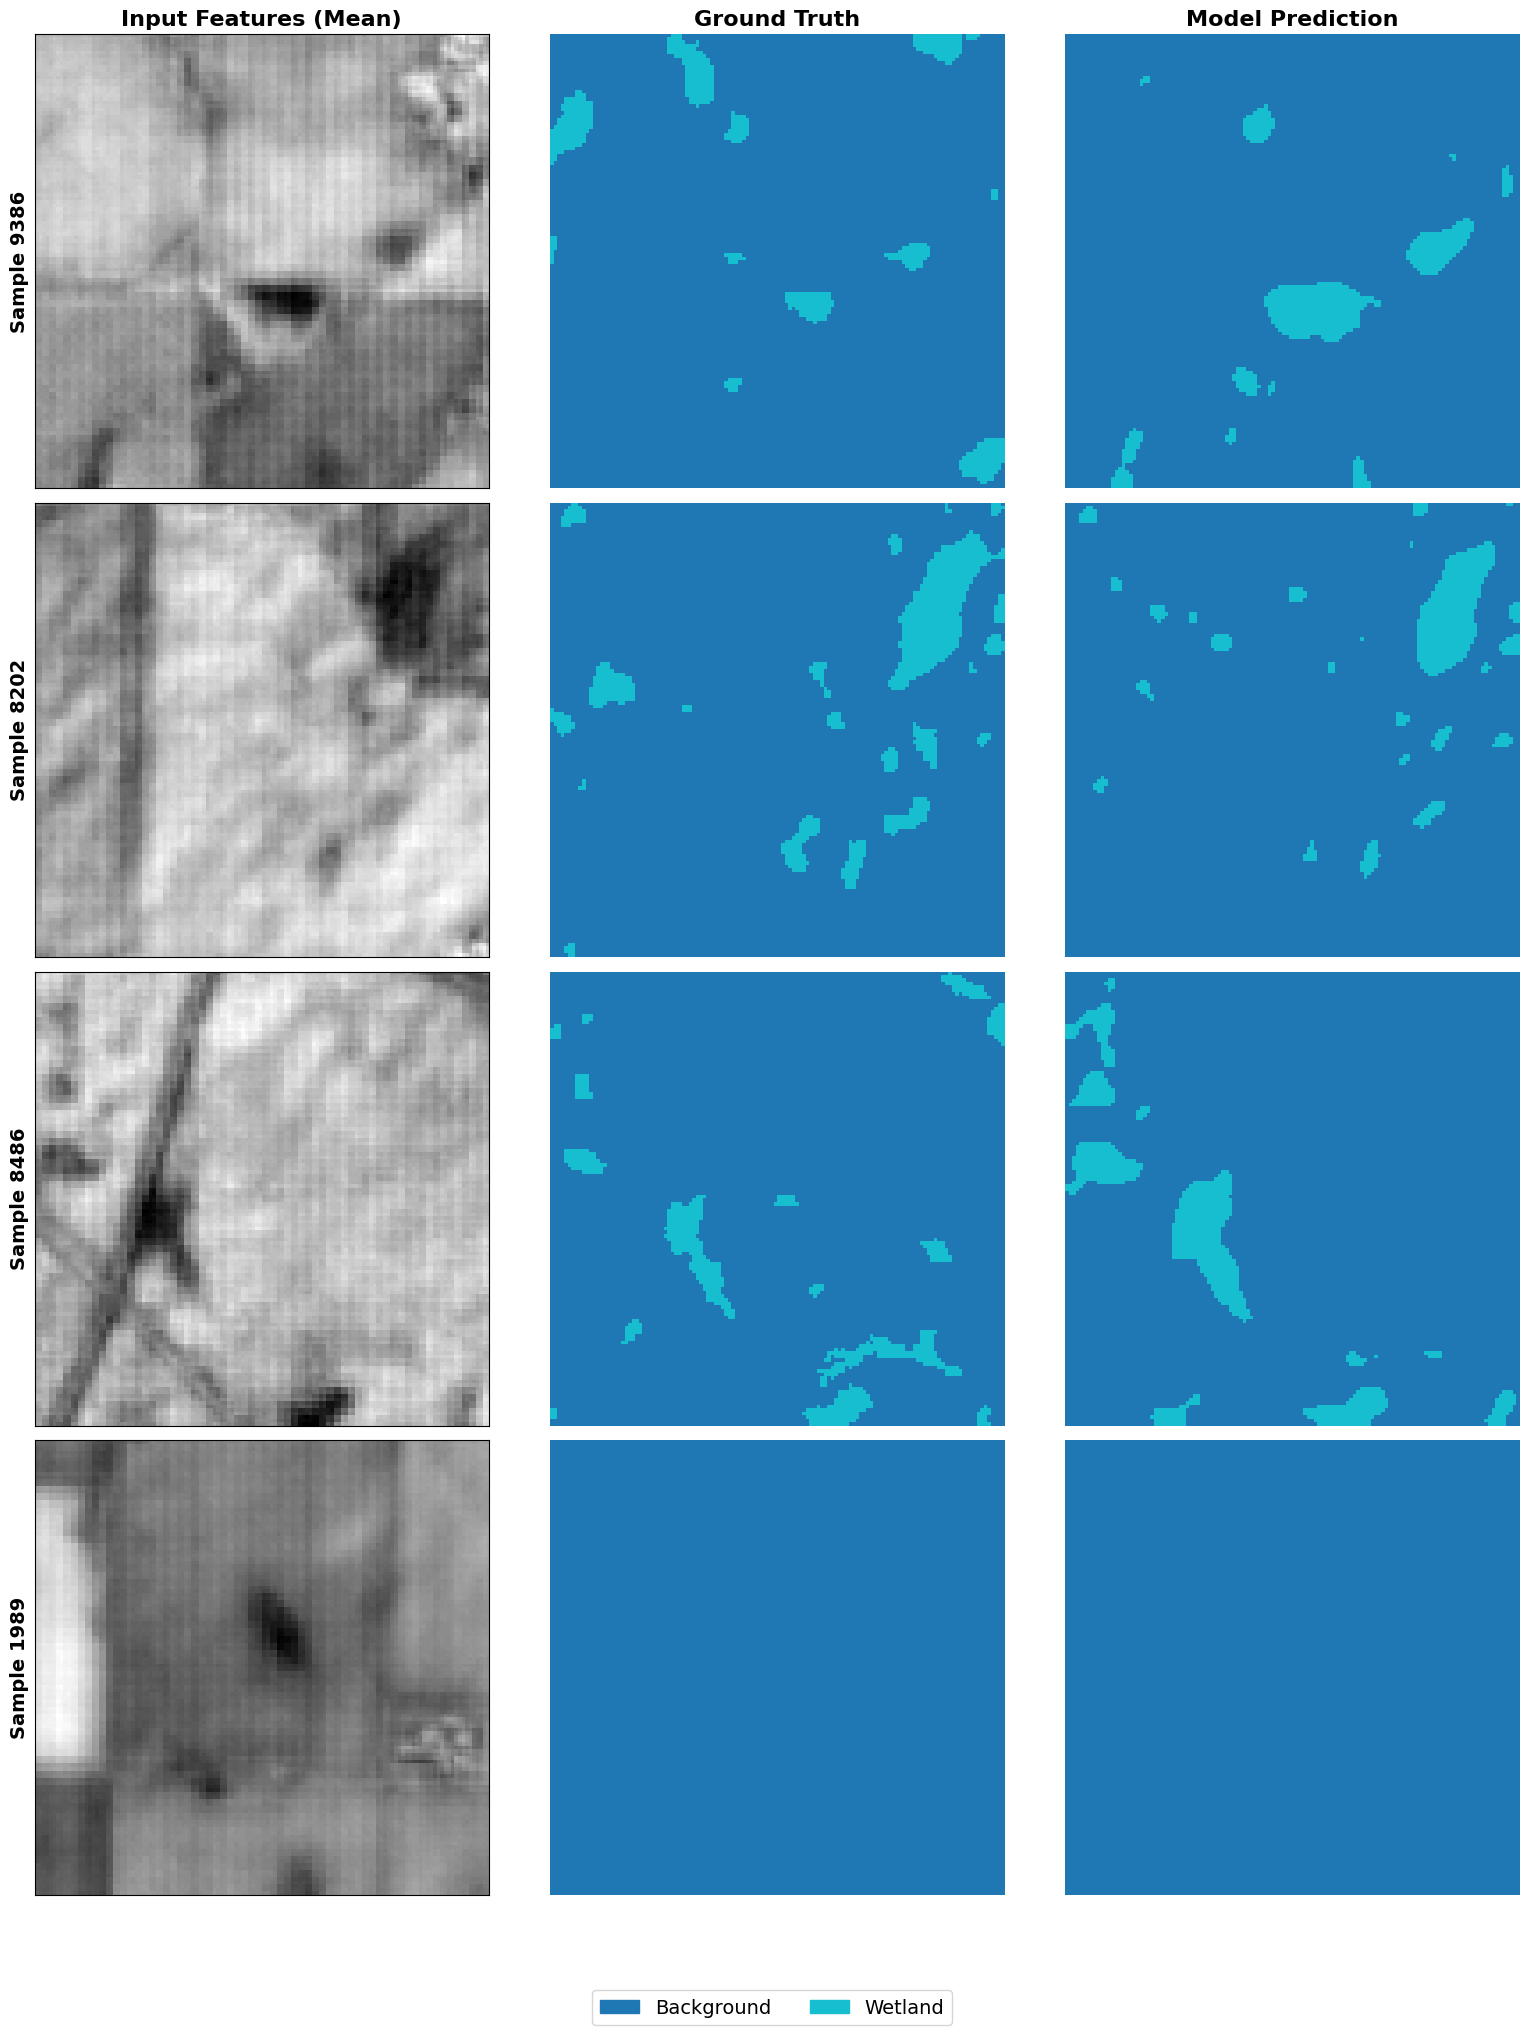

In [21]:
# ==============================================================================
# CELL 5: MULTIPLE VISUAL INFERENCE SAMPLES (V9 ARCHITECTURE)
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# --- 1. CONFIGURATION ---
NUM_SAMPLES = 4  # Change this to visualize more or fewer rows
NUM_CLASSES = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
save_path = "/content/drive/MyDrive/best_wetland_unet_v10.pth"

# Dictionary for your specific wetland classes (update names as needed)
CLASS_NAMES = {
    0: "Background",
    1: "Wetland"
}

# --- 2. MODEL SETUP ---
# Redefine the updated 64-channel architecture
class EarthEngineUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=64,
            classes=NUM_CLASSES,
            activation=None
        )

    def forward(self, x):
        return self.unet(x)

model = EarthEngineUNet().to(DEVICE)
model.load_state_dict(torch.load(save_path))
model.eval()

# --- 3. PLOTTING SETUP ---
fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(16, 5 * NUM_SAMPLES))
# Ensure axes is 2D even if NUM_SAMPLES=1
if NUM_SAMPLES == 1:
    axes = axes.reshape(1, -1)

# Pick random indices from the validation set
sample_indices = random.sample(range(len(val_dataset)), NUM_SAMPLES)

# --- 4. INFERENCE & VISUALIZATION LOOP ---
with torch.no_grad():
    for row_idx, data_idx in enumerate(sample_indices):
        image, true_mask = val_dataset[data_idx]

        # Run inference
        image_input = image.unsqueeze(0).to(DEVICE)
        with torch.amp.autocast('cuda'):
            output = model(image_input)

        pred_mask = torch.argmax(output, dim=1).cpu().squeeze().numpy()
        true_mask_vis = true_mask.squeeze().numpy()
        image_vis = image.mean(dim=0).numpy()

        # Plot Input Features (Mean of 64 Channels)
        axes[row_idx, 0].imshow(image_vis, cmap='gray')
        if row_idx == 0: axes[row_idx, 0].set_title("Input Features (Mean)", fontsize=16, fontweight='bold')
        axes[row_idx, 0].set_ylabel(f"Sample {data_idx}", fontsize=14, fontweight='bold')
        axes[row_idx, 0].set_xticks([])
        axes[row_idx, 0].set_yticks([])

        # Plot Ground Truth
        axes[row_idx, 1].imshow(true_mask_vis, cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
        if row_idx == 0: axes[row_idx, 1].set_title("Ground Truth", fontsize=16, fontweight='bold')
        axes[row_idx, 1].axis('off')

        # Plot Prediction
        im = axes[row_idx, 2].imshow(pred_mask, cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
        if row_idx == 0: axes[row_idx, 2].set_title("Model Prediction", fontsize=16, fontweight='bold')
        axes[row_idx, 2].axis('off')

# --- 5. ADD A UNIVERSAL LEGEND ---
# Extract the colors from the tab10 colormap to create a legend
cmap = plt.get_cmap('tab10')
legend_patches = [mpatches.Patch(color=cmap(i / (NUM_CLASSES-1)), label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
fig.legend(handles=legend_patches, loc='lower center', ncol=NUM_CLASSES, fontsize=14, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.05) # Make room for the legend
plt.show()

In [22]:
# ==============================================================================
# CELL 6: TWO-STAGE INFERENCE (CNN -> RF) & JSON METRICS EXPORT
# ==============================================================================
import os
import json
import torch
import joblib
import numpy as np
from datetime import datetime
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import segmentation_models_pytorch as smp
from google.colab import drive

# --- 1. SETUP & INITIALIZATION ---
drive.mount('/content/drive')
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FINAL_CLASSES = 6
CNN_CLASSES = 2
BATCH_SIZE = 32

cnn_save_path = "/content/drive/MyDrive/best_wetland_unet_v10.pth"
rf_save_path = "/content/drive/MyDrive/EarthEngine/rf_wetland_only_20260304_185037.pkl"
output_json_path = "/content/drive/MyDrive/two_stage_pipeline_results_2.json"

# Load the Random Forest
print(f"Loading RF model from {rf_save_path}...")
rf_model = joblib.load(rf_save_path)

# Define and Load the Binary U-Net
class EarthEngineUNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = smp.Unet(
            encoder_name="resnet34",
            encoder_weights=None, # Weights loaded from state_dict below
            in_channels=64,
            classes=CNN_CLASSES,
            activation=None
        )

    def forward(self, x):
        return self.unet(x)

print(f"Loading CNN model from {cnn_save_path}...")
model = EarthEngineUNet().to(DEVICE)
model.load_state_dict(torch.load(cnn_save_path))
model.eval()

# --- 2. DATASET WITH MULTI-CLASS MASKS ---
# We must use a custom dataset here because the training val_loader binarized the masks.
# This version loads both normalized images (for CNN) and raw images (for RF).
class MultiClassValDataset(Dataset):
    def __init__(self, split="val"):
        self.img_dir = os.path.join(LOCAL_EXTRACT_PATH, split, "images")
        self.mask_dir = os.path.join(LOCAL_EXTRACT_PATH, split, "masks")
        self.files = [f for f in os.listdir(self.img_dir) if f.endswith('.npy')]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        raw_img = np.load(os.path.join(self.img_dir, file_name)).astype(np.float32)
        true_mask = np.load(os.path.join(self.mask_dir, file_name)).astype(np.int64)
        norm_img = (raw_img - GLOBAL_MEAN.reshape(64, 1, 1)) / GLOBAL_STD.reshape(64, 1, 1)

        return (
            torch.tensor(norm_img, dtype=torch.float32),
            torch.tensor(raw_img, dtype=torch.float32),
            torch.tensor(true_mask, dtype=torch.long)
        )

val_mc_dataset = MultiClassValDataset(split="val")
val_mc_loader = DataLoader(val_mc_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Initialize tracking variables
global_cm = np.zeros((FINAL_CLASSES, FINAL_CLASSES), dtype=np.int64)
total_pixels_processed = 0

# --- 3. TWO-STAGE INFERENCE LOOP ---
print("\nRunning two-stage inference over the validation set...")
with torch.no_grad():
    for norm_images, raw_images, true_masks in tqdm(val_mc_loader, desc="Validating Batches"):
        norm_images = norm_images.to(DEVICE)

        # Stage 1: CNN Binary Prediction
        with torch.amp.autocast('cuda'):
            cnn_outputs = model(norm_images)
        cnn_preds = torch.argmax(cnn_outputs, dim=1).cpu().numpy()

        raw_images_flat = raw_images.numpy().transpose(0, 2, 3, 1).reshape(-1, 64)
        cnn_preds_flat = cnn_preds.reshape(-1)
        true_masks_flat = true_masks.numpy().reshape(-1)

        final_preds_flat = np.zeros_like(cnn_preds_flat)

        # Stage 2: RF Multi-Class Prediction
        wetland_mask = (cnn_preds_flat == 1)
        if wetland_mask.any():
            wetland_features = raw_images_flat[wetland_mask]
            rf_preds = rf_model.predict(wetland_features)
            final_preds_flat[wetland_mask] = rf_preds

        # Accumulate confusion matrix

        batch_cm = confusion_matrix(true_masks_flat, final_preds_flat, labels=np.arange(FINAL_CLASSES))
        global_cm += batch_cm
        total_pixels_processed += len(true_masks_flat)

# --- 4. METRIC DERIVATION ---
support = global_cm.sum(axis=1)
total_support = support.sum()
tp = np.diag(global_cm)
fp = global_cm.sum(axis=0) - tp
fn = global_cm.sum(axis=1) - tp

# Core metrics (with 1e-10 to prevent division by zero)
precision = tp / (tp + fp + 1e-10)
recall = tp / (tp + fn + 1e-10)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)
iou = tp / (tp + fp + fn + 1e-10)

accuracy = tp.sum() / total_support
weights = support / total_support

precision_weighted = np.sum(precision * weights)
recall_weighted = np.sum(recall * weights)
f1_weighted = np.sum(f1_score * weights)
iou_macro = np.mean(iou)

# --- 5. FORMAT DICTIONARY FOR JSON ---
per_class_metrics = {}
class_names = ["Background", "Bog", "Fen", "Marsh", "Swamp", "Open Water"]

for i in range(FINAL_CLASSES):
    per_class_metrics[class_names[i]] = {
        "class_id": i,
        "precision": float(precision[i]),
        "recall": float(recall[i]),
        "f1_score": float(f1_score[i]),
        "iou": float(iou[i]),
        "support": int(support[i])
    }

evaluation_results = {
    "version": "Two-Stage Pipeline 1.0",
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "overall_metrics": {
        "accuracy": float(accuracy),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
        "iou_macro": float(iou_macro)
    },
    "per_class_metrics": per_class_metrics,
    "confusion_matrix": global_cm.tolist(),
    "confusion_matrix_labels": class_names,
    "architecture": {
        "stage_1_model": "smp.Unet (Binary Wetland Masking)",
        "stage_1_encoder": "resnet34",
        "stage_2_model": "RandomForestClassifier (Multi-Class Filtering)",
        "stage_2_source": "rf_wetland_only_20260304_185037.pkl"
    },
    "dataset": {
        "n_test_patches": len(val_mc_dataset),
        "n_features": 64,
        "total_test_pixels": int(total_pixels_processed)
    }
}

# --- 6. EXPORT TO JSON ---
with open(output_json_path, 'w') as json_file:
    json.dump(evaluation_results, json_file, indent=4)

print(f"\n✅ Validation complete! Results saved to: {output_json_path}")
print(f"Overall Accuracy: {accuracy:.4f} | Weighted F1: {f1_weighted:.4f} | Macro IoU: {iou_macro:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading RF model from /content/drive/MyDrive/EarthEngine/rf_wetland_only_20260304_185037.pkl...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading CNN model from /content/drive/MyDrive/best_wetland_unet_v10.pth...

Running two-stage inference over the validation set...


Validating Batches:   0%|          | 0/398 [00:00<?, ?it/s][Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    1.4s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.8s finished
Validating Batches:   0%|          | 1/398 [00:05<34:26,  5.21s/it][Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.5s finished
Validating Batches:   1%|          | 2/398 [00:07<23:08,  3.51s/it][Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.1s 


✅ Validation complete! Results saved to: /content/drive/MyDrive/two_stage_pipeline_results_2.json
Overall Accuracy: 0.9320 | Weighted F1: 0.9274 | Macro IoU: 0.3283
